**0. Import requireed modules**

In [ ]:
!unzip /content/resourcemanager.zip -d /content/resourcemanager_java_files

Archive:  /content/resourcemanager.zip
   creating: /content/resourcemanager_java_files/resourcemanager/
  inflating: /content/resourcemanager_java_files/resourcemanager/ActiveStandbyElectorBasedElectorService.java  
  inflating: /content/resourcemanager_java_files/resourcemanager/AdminService.java  
   creating: /content/resourcemanager_java_files/resourcemanager/ahs/
  inflating: /content/resourcemanager_java_files/resourcemanager/ahs/RMApplicationHistoryWriter.java  
  inflating: /content/resourcemanager_java_files/resourcemanager/ahs/WritingApplicationAttemptFinishEvent.java  
  inflating: /content/resourcemanager_java_files/resourcemanager/ahs/WritingApplicationAttemptStartEvent.java  
  inflating: /content/resourcemanager_java_files/resourcemanager/ahs/WritingApplicationFinishEvent.java  
  inflating: /content/resourcemanager_java_files/resourcemanager/ahs/WritingApplicationHistoryEvent.java  
  inflating: /content/resourcemanager_java_files/resourcemanager/ahs/WritingApplication

In [ ]:
pip install -U bitsandbytes>=0.46.1

In [ ]:
import numpy as np
import torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from google.colab import userdata
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from collections import defaultdict
import json

**1. Provide the path of java files and load their source code into a list**

In [ ]:
SOURCE_CODE_DIR = Path("/content/resourcemanager_java_files/resourcemanager")  # upload your java files folder here
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
files_list = []   # stores file content
file_paths = []   # stores file paths (needed to match back to class names later)

for file_path in SOURCE_CODE_DIR.rglob('*.java'):
    if file_path.is_file():
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            files_list.append(f.read())
            file_paths.append(str(file_path))

print(f"Total Java files loaded: {len(files_list)}")

Total Java files loaded: 749


**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [ ]:
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

**3. Hardware optimization (Quantization)**

In [ ]:
# The model WEIGHTS are loaded in 4-bit, reducing memory from ~6GB to ~1.5GB
# This is needed to fit the embedding model alongside other operations on the T4 GPU
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

**4. Generate embeddings**

In [ ]:
# Group 5 primary embedding model
embedding_model_name = "nomic-ai/CodeRankEmbed"

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

embedding_model_name = "nomic-ai/nomic-embed-text-v1.5"

print(f"Loading tokenizer for {embedding_model_name}...")

tokenizer = AutoTokenizer.from_pretrained(
    embedding_model_name,
    token=hf_token,
    trust_remote_code=True
)

print("Loading model...")

model = AutoModel.from_pretrained(
    embedding_model_name,
    token=hf_token,
    trust_remote_code=True,
    device_map="auto"
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print(f"Using device: {device}")

Loading tokenizer for nomic-ai/nomic-embed-text-v1.5...


config.json: 0.00B [00:00, ?B/s]

configuration_hf_nomic_bert.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nomic-ai/nomic-bert-2048:
- configuration_hf_nomic_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Loading model...


modeling_hf_nomic_bert.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nomic-ai/nomic-bert-2048:
- modeling_hf_nomic_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/547M [00:00<?, ?B/s]

Using device: cuda


**5. Construct the semantic similarity matrix**

In [ ]:
def embed_source_code(code_files):

    embeddings = []

    for i, code in enumerate(code_files):

        print(f"Embedding file {i+1}/{len(code_files)}...", end="\r")

        inputs = tokenizer(
            code,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():

            outputs = model(**inputs)

        # Mean pooling
        embedding = outputs.last_hidden_state.mean(dim=1)

        embeddings.append(
            embedding.float().cpu().numpy()[0]
        )

    return np.array(embeddings)

In [ ]:
embeddings = embed_source_code(files_list)

semantic_matrix = cosine_similarity(embeddings)

print("Semantic matrix shape:")
print(semantic_matrix.shape)

Semantic matrix shape:
(749, 749)


**6. Construct the structural similarity matrix**

In [ ]:
# scan the filtered .rsf dependency file from week 1 to construct a matrix where each entry is the number of packages each pair of files depend on.
# executing this cell produces 'struct_matrix_raw'
# Upload filtered_rsf.rsf to Colab first
RSF_PATH = "/content/filtered_rsf.rsf"

# Build an index mapping file paths to matrix positions
# We match class names from the RSF to file paths from Cell 1
def class_to_file_index(file_paths):
    """Map fully qualified class name to its index in file_paths list"""
    index = {}
    for i, fp in enumerate(file_paths):
        # Convert path like .../org/apache/hadoop/mapreduce/Job.java
        # to org.apache.hadoop.mapreduce.Job
        parts = fp.replace("/", ".").replace("\\", ".")
        for j in range(len(parts)):
            if "org.apache.hadoop" in parts[j:]:
                class_name = parts[j:].replace(".java", "")
                class_name = class_name[class_name.find("org.apache.hadoop"):]
                index[class_name] = i
                break
    return index

class_index = class_to_file_index(file_paths)
n = len(file_paths)

struct_matrix_raw = np.zeros((n, n))

with open(RSF_PATH, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 3 and parts[0] == "depends":
            src, tgt = parts[1], parts[2]
            if src in class_index and tgt in class_index:
                i, j = class_index[src], class_index[tgt]
                struct_matrix_raw[i][j] += 1
                struct_matrix_raw[j][i] += 1  # make it symmetric

print(f"Structural matrix shape: {struct_matrix_raw.shape}")
print(f"Non-zero entries: {np.count_nonzero(struct_matrix_raw)}")
np.save("/content/output/struct_matrix_raw.npy", struct_matrix_raw)
print("✅ Structural matrix saved.")

Structural matrix shape: (749, 749)
Non-zero entries: 0
✅ Structural matrix saved.


**7. Normalize the structural matrix**

In [ ]:
max_overlap = struct_matrix_raw.max()
struct_matrix = struct_matrix_raw / max_overlap if max_overlap > 0 else struct_matrix_raw
np.fill_diagonal(struct_matrix, 1.0)
print(f"Structural matrix normalized. Max value: {struct_matrix.max():.3f}, Min: {struct_matrix.min():.3f}")

Structural matrix normalized. Max value: 1.000, Min: 0.000


**8. Combine the two matrices into one similarity matrix then apply complement.**

In [ ]:
# ALPHA: weight of structural vs semantic similarity
# 0.5 = 50% structural + 50% semantic
# Tune this based on your evaluation results
ALPHA = 0.5

combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Invert to get distance matrix (required for AgglomerativeClustering with precomputed metric)
distance_matrix = 1.0 - combined_similarity
np.fill_diagonal(distance_matrix, 0)

print(f"Combined similarity range: {combined_similarity.min():.3f} – {combined_similarity.max():.3f}")
print(f"Distance matrix range: {distance_matrix.min():.3f} – {distance_matrix.max():.3f}")
np.save("/content/output/distance_matrix.npy", distance_matrix)
print("✅ Distance matrix saved.")

Combined similarity range: 0.336 – 1.000
Distance matrix range: 0.000 – 0.664
✅ Distance matrix saved.


**9. Apply clustering**

In [ ]:
# TARGET_NUM_CLUSTERS:
# Tune later using a2a and cvg

TARGET_NUM_CLUSTERS = 10

clusterer = AgglomerativeClustering(
    n_clusters=TARGET_NUM_CLUSTERS,
    metric='precomputed',
    linkage='average'
)

clusters = clusterer.fit_predict(distance_matrix)

# Save ARC clustering output
rsf_output_path = "/content/output/semantic_clusters.rsf"

with open(rsf_output_path, "w") as f:

    for file_idx, cluster_id in enumerate(clusters):

        class_name = file_paths[file_idx]

        class_name = class_name.replace("/", ".")
        class_name = class_name.replace("\\", ".")

        if "org.apache.hadoop" in class_name:

            class_name = class_name[
                class_name.find("org.apache.hadoop") :
            ]

        class_name = class_name.replace(".java", "")

        f.write(
            f"contain cluster{cluster_id} {class_name}\n"
        )

print(f"✅ Clustering done!")
print(f"✅ RSF saved to: {rsf_output_path}")

✅ Clustering done!
✅ RSF saved to: /content/output/semantic_clusters.rsf


**10. Visulizations**

/tmp/ipykernel_8761/627440151.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = sch.linkage(distance_matrix, method='average')


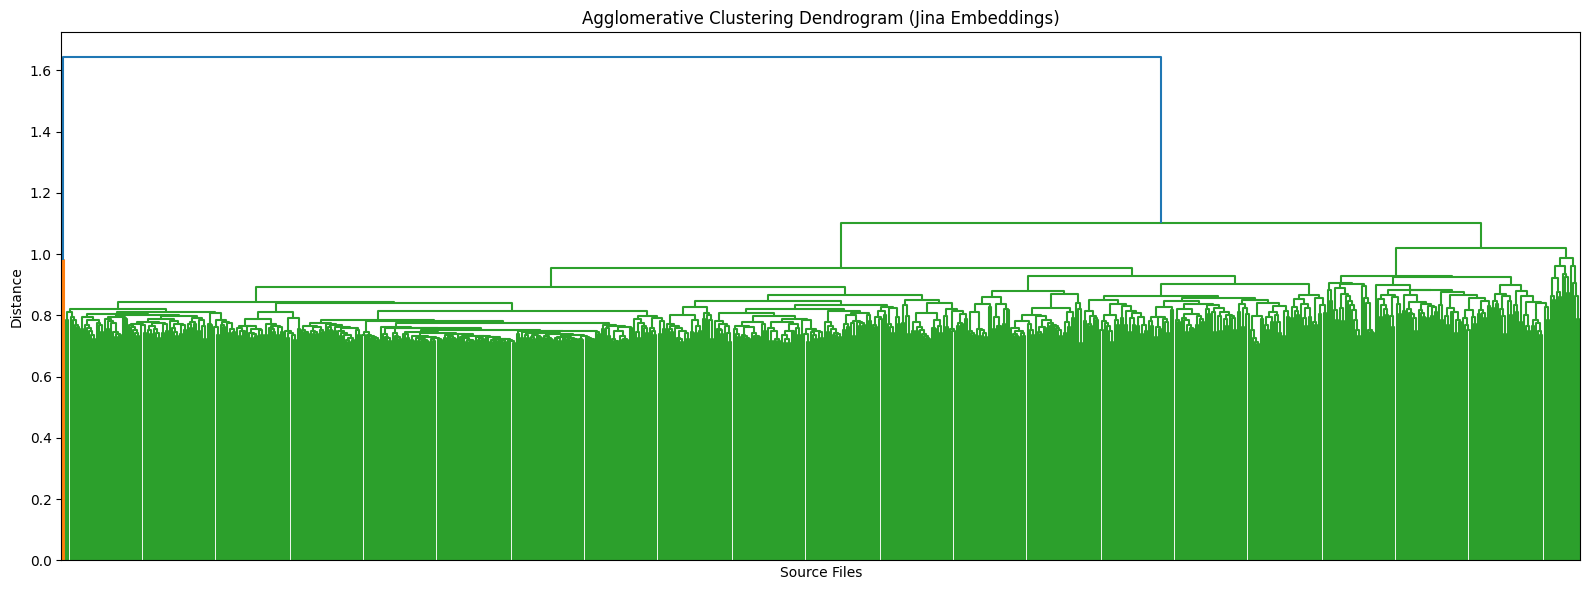

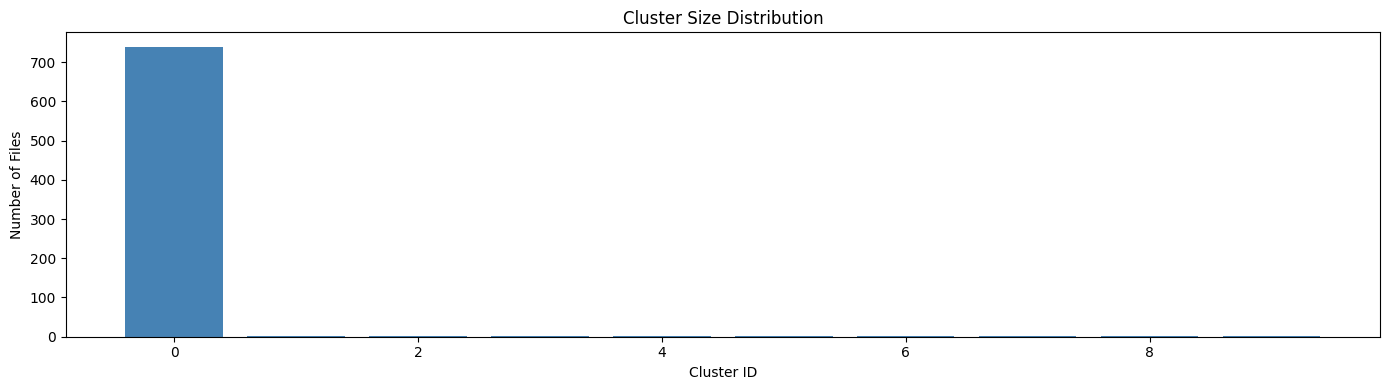

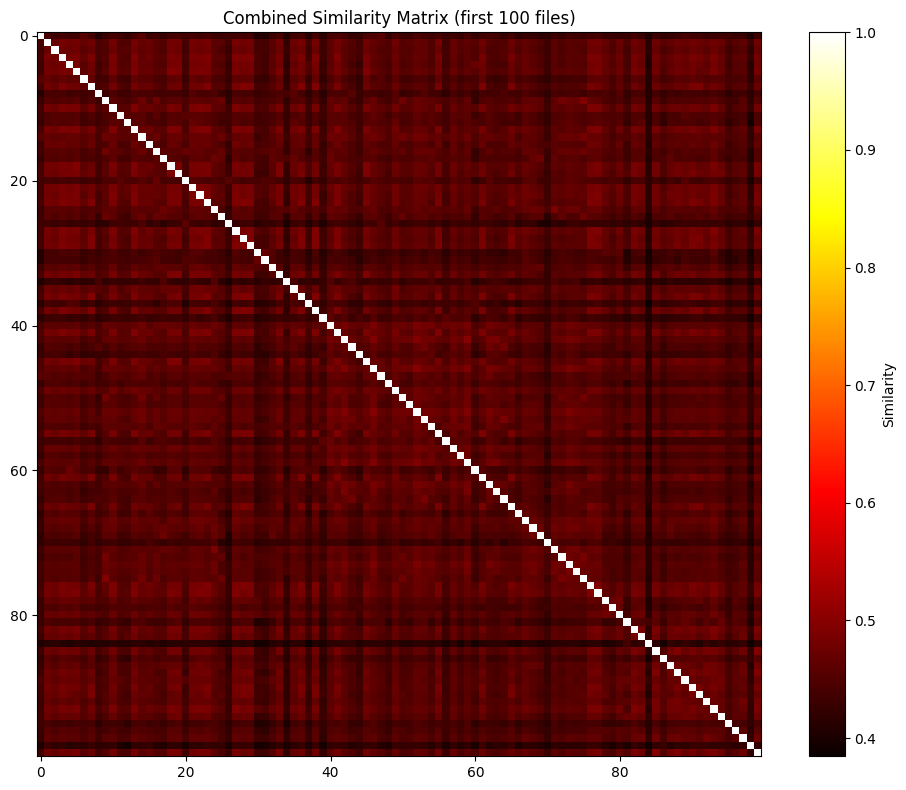

✅ All visualizations saved to /content/output/


In [ ]:
# According to the applied algorithm documentation, provide any visualizations for better understanding of how the clusters are formed.
# 1. Dendrogram — shows how files were merged into clusters
plt.figure(figsize=(16, 6))
linked = sch.linkage(distance_matrix, method='average')
sch.dendrogram(linked, no_labels=True)
plt.title("Agglomerative Clustering Dendrogram (Jina Embeddings)")
plt.xlabel("Source Files")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("/content/output/dendrogram.png", dpi=150)
plt.show()

# 2. Cluster size distribution
unique, counts = np.unique(clusters, return_counts=True)
plt.figure(figsize=(14, 4))
plt.bar(unique, counts, color="steelblue")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Files")
plt.tight_layout()
plt.savefig("/content/output/cluster_sizes.png", dpi=150)
plt.show()

# 3. Heatmap of combined similarity matrix (sampled for visibility)
sample_size = min(100, len(file_paths))
plt.figure(figsize=(10, 8))
plt.imshow(combined_similarity[:sample_size, :sample_size], cmap="hot", interpolation="nearest")
plt.colorbar(label="Similarity")
plt.title(f"Combined Similarity Matrix (first {sample_size} files)")
plt.tight_layout()
plt.savefig("/content/output/similarity_heatmap.png", dpi=150)
plt.show()

print("✅ All visualizations saved to /content/output/")